In [43]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt 

In [44]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

ISLP Applied exercise
Q8: Using the Auto data set. 

In [45]:
Auto=load_data('Auto')
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


In [46]:
# Simple linear regression using mpg as response and horsepower as the predictor. 
# setting up an additional column that consists of ones which represent an intercept constant. 
X=pd.DataFrame({'intercept':np.ones(Auto.shape[0]), 'horsepower':Auto['horsepower']})
X[:6]


,intercept,horsepower
name,,
chevrolet chevelle malibu,1.0,130
buick skylark 320,1.0,165
plymouth satellite,1.0,150
amc rebel sst,1.0,150
ford torino,1.0,140
ford galaxie 500,1.0,198


In [47]:
# setting up the response variable
y=Auto['mpg']

In [48]:
model=sm.OLS(y, X)
result=model.fit()
summarize(result)


,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [49]:
design=MS(['horsepower'])
X=design.fit_transform(Auto)
X[:4]

,intercept,horsepower
name,,
chevrolet chevelle malibu,1.0,130
buick skylark 320,1.0,165
plymouth satellite,1.0,150
amc rebel sst,1.0,150


In [50]:
new_df=pd.DataFrame({'horsepower':[98]})

# the model has already learnt the rules and calculated statistical metrics like std dev on the entire dataset, therefore we only call transform and not fit and transform
newX=design.transform(new_df)
newX

,intercept,horsepower
0,1.0,98


In [51]:
new_predictions=result.get_prediction(newX);
prediction_summary=new_predictions.summary_frame(alpha=0.05)
print(prediction_summary)

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  24.467077  0.251262      23.973079      24.961075     14.809396   

   obs_ci_upper  
0     34.124758  


i. Yes, p-value is 0.00 (<0.05), indicating a statistically significant relationship.

ii. Very strong relationship, indicated by a massive t-statistic of -24.489.

iii. Negative relationship (coefficient = -0.1578); higher horsepower predicts lower mpg.

iv. CI=[LL:23.973079, UL:24.961075] Prediction interval=[lower: 14.809396, upper:34.124758  ]


b) Plotting the response and predictor

In [52]:
# defining a function to plot
def abline(ax, b, m, *args, **kwargs):
    xlim=ax.get_xlim()
    ylim=[m*xlim[0]+b, m*xlim[1]+b]
    ax.plot(xlim, ylim, *args, **kwargs)


/var/folders/0g/0rngkrh11rz7p3c55850pvjc0000gn/T/ipykernel_1611/1806034391.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, result.params[0], result.params[1], 'r--', linewidth=3)


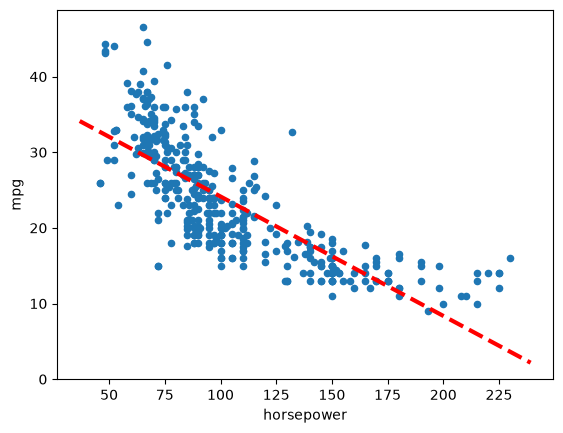

In [53]:
ax=Auto.plot.scatter('horsepower','mpg')
abline(ax, result.params[0], result.params[1], 'r--', linewidth=3)

c) Diagnostic plots of least regression

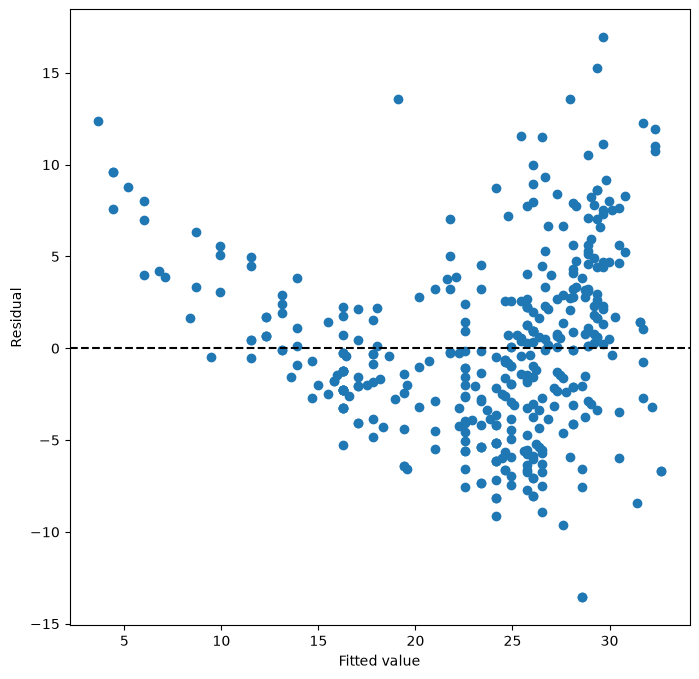

In [54]:
ax=subplots(figsize=(8,8))[1]
ax.scatter(result.fittedvalues, result.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

Text(0, 0.5, 'Leverage')

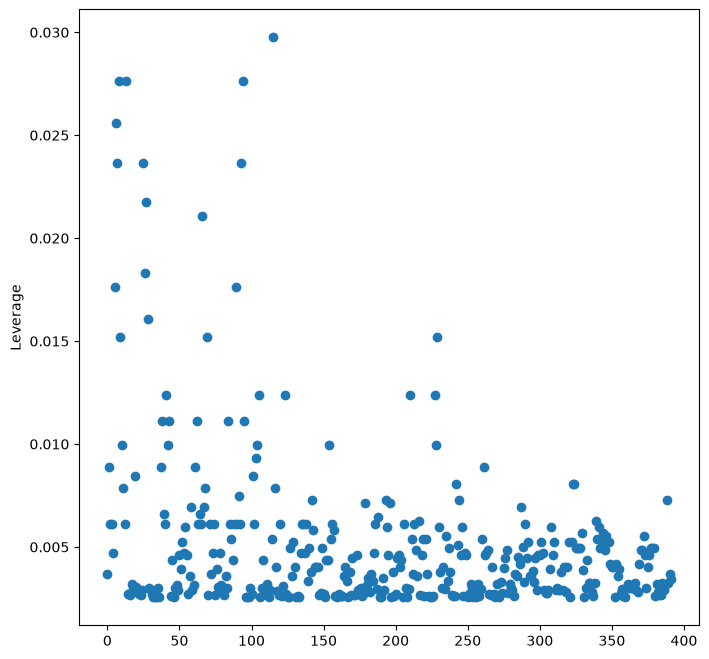

In [55]:
infl=result.get_influence()
ax=subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_label('Index')
ax.set_ylabel('Leverage')

Q9) Multiple linear regression for Auto data set. 

In [56]:
all_variables=Auto.columns
all_variables

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='horsepower', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement

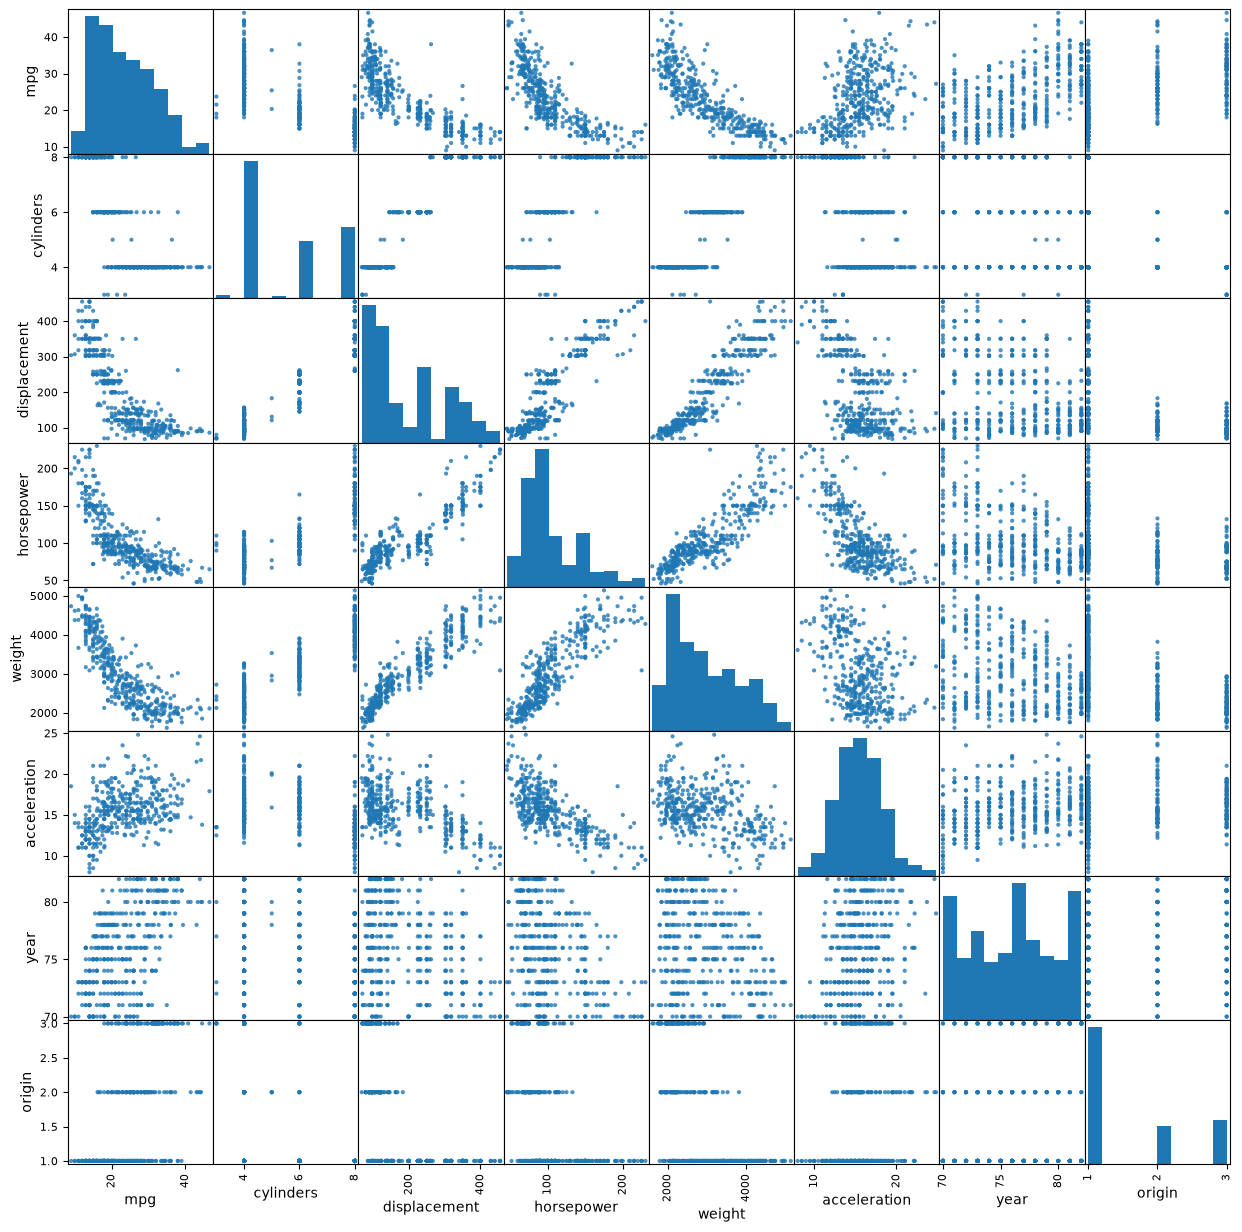

In [57]:
df=pd.DataFrame(Auto[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin']], columns=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'])
pd.plotting.scatter_matrix(df, alpha=0.8, figsize=(15,15))

Producing matrix correlations

In [58]:
df.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


Performing multiple linear regression on the Auto dataset. 

In [59]:
all_variables=list(Auto.columns.drop('mpg'))
y=Auto['mpg']
X=MS(all_variables).fit_transform(Auto)
model=sm.OLS(y, X)
result=model.fit()
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [60]:
# 1. Create a quick null model (intercept only)
X_null = sm.add_constant(pd.DataFrame(index=Auto.index))
null_result = sm.OLS(y, X_null).fit()

sm.stats.anova_lm(null_result, result)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,391.0,23818.993469,0.0,NaN,NaN,NaN
1,384.0,4252.212530,7.0,19566.780939,252.428045,2.037106e-139


Diagnostic plots 

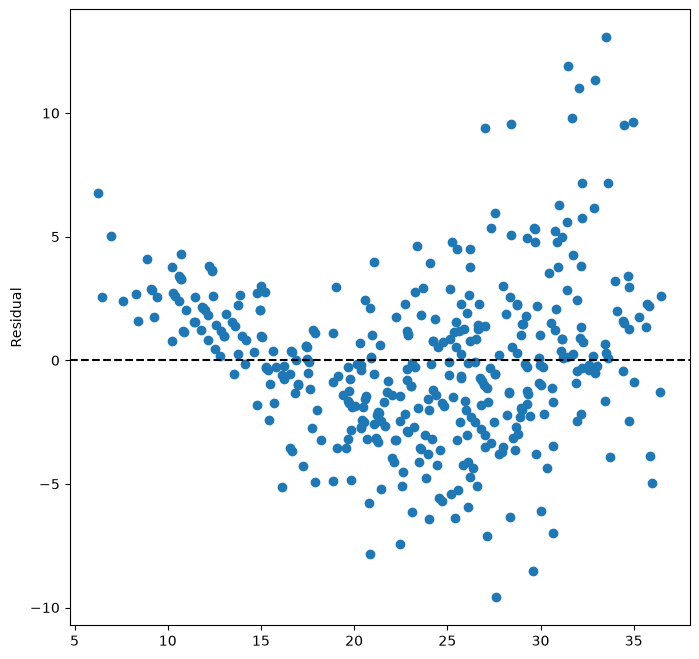

In [61]:
ax=subplots(figsize=(8,8))[1]
ax.scatter(result.fittedvalues, result.resid)
ax.set_label('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

Text(0, 0.5, 'Leverage')

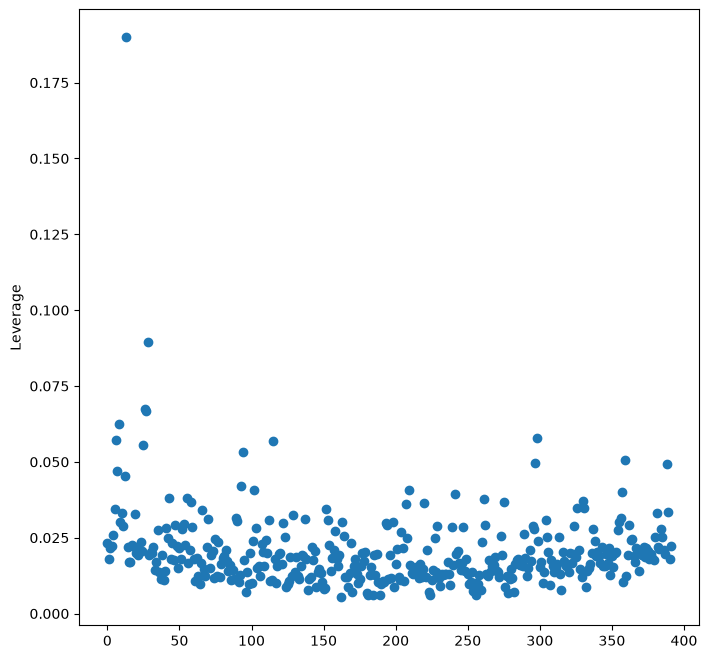

In [62]:
infl=result.get_influence()
ax=subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_label('Index')
ax.set_ylabel('Leverage')

Interaction models 

In [63]:
all_variables=list(Auto.columns.drop('mpg'))
y=Auto['mpg']

given our multiple linear regression model, the following variables hold statistical significance: displacement, weight, year and origin. 

In [64]:
all_variables

['cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'year',
 'origin']

In [65]:
# interaction 1: displacement and weight

disp_weight=all_variables+[('displacement', 'weight')]
X=MS(disp_weight).fit_transform(Auto)
model=sm.OLS(y, X)
summarize(model.fit())
# An increase in either weight or displacement results in decreased mpg. However, sicne the interaction term is positive, we can conclude that -ve impact of higher displacement becomes less severe due when weight increases. 

,coef,std err,t,P>|t|
intercept,-5.389200,4.301000,-1.253,0.211
cylinders,0.117500,0.294000,0.399,0.690
displacement,-0.068400,0.011000,-6.193,0.000
horsepower,-0.032800,0.012000,-2.649,0.008
weight,-0.010600,0.001000,-14.915,0.000
acceleration,0.067200,0.088000,0.764,0.446
year,0.785200,0.046000,17.246,0.000
origin,0.561000,0.262000,2.139,0.033
displacement:weight,0.000023,0.000002,10.054,0.000


In [66]:
# interactoin term 2: year and origin
year_origin=all_variables+[('year', 'origin')]
X=MS(year_origin).fit_transform(Auto)
model=sm.OLS(y, X)
summarize(model.fit())
# incorrect interaction. Origin is a categorical value which will have to be transformed using once hot encoding

,coef,std err,t,P>|t|
intercept,8.4915,9.044,0.939,0.348
cylinders,-0.5042,0.319,-1.579,0.115
displacement,0.0157,0.008,2.081,0.038
horsepower,-0.0140,0.014,-1.025,0.306
weight,-0.0064,0.001,-9.851,0.000
acceleration,0.0918,0.098,0.941,0.348
year,0.4189,0.113,3.723,0.000
origin,-14.0456,4.699,-2.989,0.003
year:origin,0.1989,0.060,3.298,0.001


In [67]:
X

,intercept,cylinders,displacement,horsepower,weight,acceleration,year,origin,year:origin
name,,,,,,,,,
chevrolet chevelle malibu,1.0,8,307.0,130,3504,12.0,70,1,70.0
buick skylark 320,1.0,8,350.0,165,3693,11.5,70,1,70.0
plymouth satellite,1.0,8,318.0,150,3436,11.0,70,1,70.0
amc rebel sst,1.0,8,304.0,150,3433,12.0,70,1,70.0
ford torino,1.0,8,302.0,140,3449,10.5,70,1,70.0
...,...,...,...,...,...,...,...,...,...
ford mustang gl,1.0,4,140.0,86,2790,15.6,82,1,82.0
vw pickup,1.0,4,97.0,52,2130,24.6,82,2,164.0
dodge rampage,1.0,4,135.0,84,2295,11.6,82,1,82.0


In [68]:
# one hot encoding. 
encoded_df=pd.get_dummies(X, columns=['origin'])
encoded_df=encoded_df.drop(columns=["origin_1", "year:origin"])
encoded_variables=encoded_df.columns
encoded_df



,intercept,cylinders,displacement,horsepower,weight,acceleration,year,origin_2,origin_3
name,,,,,,,,,
chevrolet chevelle malibu,1.0,8,307.0,130,3504,12.0,70,False,False
buick skylark 320,1.0,8,350.0,165,3693,11.5,70,False,False
plymouth satellite,1.0,8,318.0,150,3436,11.0,70,False,False
amc rebel sst,1.0,8,304.0,150,3433,12.0,70,False,False
ford torino,1.0,8,302.0,140,3449,10.5,70,False,False
...,...,...,...,...,...,...,...,...,...
ford mustang gl,1.0,4,140.0,86,2790,15.6,82,False,False
vw pickup,1.0,4,97.0,52,2130,24.6,82,True,False
dodge rampage,1.0,4,135.0,84,2295,11.6,82,False,False


In [69]:
encoded_variables

Index(['intercept', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin_2', 'origin_3'],
      dtype='object')

In [70]:
#encoded_variables=encoded_variables+[('year', 'origin_2'), ('year', 'origin_3')]
#X=MS(encoded_variables).fit_transform(Auto)
#model=sm.OLS(y, X)
#summarize(model.fit())
Auto['origin_2']=encoded_df['origin_2']
Auto['origin_3']=encoded_df['origin_3']
encoded_variables = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin_2', 'origin_3']
encoded_variables=encoded_variables+[('year', 'origin_2'), ('year', 'origin_3')]
X=MS(encoded_variables).fit_transform(Auto)
model=sm.OLS(y, X)
summarize(model.fit())




,coef,std err,t,P>|t|
intercept,-3.8202,5.693,-0.671,0.503
cylinders,-0.5289,0.315,-1.680,0.094
displacement,0.0193,0.008,2.541,0.011
horsepower,-0.0159,0.013,-1.179,0.239
weight,-0.0066,0.001,-10.246,0.000
acceleration,0.0737,0.097,0.764,0.445
year,0.6004,0.066,9.050,0.000
origin_2,-36.2844,10.237,-3.544,0.000
origin_3,-24.4768,9.420,-2.598,0.010
year:origin_2,0.5077,0.134,3.792,0.000


Non linear transformation of the predictors. 

In [71]:
X=MS([poly('horsepower', degree=2), 'weight']).fit_transform(Auto)
model=sm.OLS(y, X)
result=model.fit()
summarize(result)

,coef,std err,t,P>|t|
intercept,36.7952,1.529,24.069,0.0
"poly(horsepower, degree=2)[0]",-55.0379,8.402,-6.551,0.0
"poly(horsepower, degree=2)[1]",30.2436,4.296,7.040,0.0
weight,-0.0045,0.001,-8.809,0.0


# Question 10 using car seats dataset

In [72]:
Car_seats=load_data('Carseats')
Car_seats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [73]:
y=Car_seats['Sales']

In [78]:
X=MS(['Price', 'Urban', 'US']).fit_transform(Car_seats)
model=sm.OLS(y, X)
result=model.fit()
summarize(result)

,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000
